# Exploración y Preparación de Datos: Matrícula Asegurada SAE 2019
**Autor:** Cristian Riquelme | Analista de Datos

## 1. Configuración del Entorno
Importación de librerías y definición de las rutas a los archivos crudos (raw data).

In [3]:
import pandas as pd
import os

# Creación de directorio de salida si no existe
os.makedirs('../data/processed', exist_ok=True)

# Diccionario de rutas para mantener el código limpio y parametrizado
RUTAS = {
    'ficha': '../data/raw/SIGE_SAE_LOG_FICHA_CUPO_versionTest.csv',
    'log': '../data/raw/SIGE_SAE_LOG_CUPO_versionTest.csv',
    'anexo': '../data/raw/SIGE_SAE_LOG_ANEXO_SEDE_versionTest.csv',
    'admi': '../data/raw/ADMI_CURSO_versionTest.csv',
    'coles': '../data/raw/colesSAE_versionTest.csv',
    'oferta_test': '../data/raw/1_oferta_2019_test.csv',
    'fusiones': '../data/raw/fusionesAnexos_versionTest.csv',
    'codigos_nivel': '../data/raw/codigos_ens_grado_a_nivel_versionTest.csv',
    'matricula': '../data/raw/MATRICULA2018_versionTest.csv'
}

## 2. Ingesta de Datos y Manejo de Inconsistencias (El problema del separador)

**Hallazgo durante el EDA (Exploratory Data Analysis):** 
Al intentar realizar una lectura estándar de los archivos, se detectó una heterogeneidad en la estructura de los CSV provistos por el Ministerio. Mientras algunos archivos usan el estándar coma (`.csv`), otros utilizan punto y coma (`;`) y algunos, como el registro de logs, utilizan *pipes* (`|`). 

**Solución Implementada:**
Para no forzar la lectura manual archivo por archivo, se desarrolla una función de enrutamiento dinámico (`cargar_csv_seguro`) que itera sobre los posibles separadores y asegura la codificación `latin-1` (necesaria para caracteres del español como tildes y ñ).

In [4]:
def cargar_csv_seguro(ruta, usecols=None, nrows=None, dtype=None):
    """
    Función para ingesta de datos.
    Intenta iterativamente distintos separadores para evitar fallos de lectura.
    Normaliza automáticamente los nombres de las columnas.
    """
    separadores = ['|', ';', ',']
    
    for sep in separadores:
        try:
            df = pd.read_csv(ruta, sep=sep, encoding='latin-1', usecols=usecols, nrows=nrows, dtype=dtype, low_memory=False)
            
            if usecols is None and len(df.columns) == 1:
                continue 
                
            # Normalización estricta de nombres de columnas
            df.columns = df.columns.str.strip().str.lower()
            return df
            
        except Exception:
            continue
            
    raise ValueError(f"Fallo crítico: No se pudieron parsear las columnas en {ruta}")

# Prueba con columnas de las tablas auxiliares para validar la función y explorar nombres.
print("Validación de lectura de columnas:")
print("1. Ficha Cupo:", cargar_csv_seguro(RUTAS['ficha'], nrows=1).columns.tolist()[:3], "...")
print("2. Log Cupo:", cargar_csv_seguro(RUTAS['log'], nrows=1).columns.tolist()[:3], "...")
print("3. Coles SAE:", cargar_csv_seguro(RUTAS['coles'], nrows=1).columns.tolist()[:3], "...")

Validación de lectura de columnas:
1. Ficha Cupo: ['rbd', 'tipo_alumnado', 'id_log_ficha_cupo'] ...
2. Log Cupo: ['rbd', 'id_log_cupo', 'fecha_ultima_actualizacion'] ...
3. Coles SAE: ['rbd', 'nombre', 'cod_reg'] ...


## 3. Desarrollo del Paso 1: Oferta 2019
Con la ingesta estabilizada, procedemos a cruzar las 5 tablas auxiliares para determinar los cursos que efectivamente tendrán continuidad en 2019, aplicando las reglas de negocio del protocolo (Vitrina activa, última fecha de actualización, validación de anexos y cruce con matriz oficial).

In [5]:
# Carga de tablas
df_ficha = cargar_csv_seguro(RUTAS['ficha'])
df_log = cargar_csv_seguro(RUTAS['log'], dtype={"rbd": "Int64", "id_log_cupo": "Int64"})
df_anexo = cargar_csv_seguro(RUTAS['anexo'])
df_admi = cargar_csv_seguro(RUTAS['admi'])
df_coles = cargar_csv_seguro(RUTAS['coles'], dtype={"rbd": "Int64"})

# Regla 1: Última actualización por ID_LOG_CUPO
df_log['fecha_ultima_actualizacion'] = pd.to_datetime(df_log['fecha_ultima_actualizacion'], errors="coerce")
log_valido = df_log[df_log['cargado_vitrina'] == 1].copy()

# Ordenamos y nos quedamos con la última actualización por cada declaración
log_valido = log_valido.sort_values(["rbd", "fecha_ultima_actualizacion", "id_log_cupo"])
log_valido = log_valido.drop_duplicates(subset=["rbd", "id_log_cupo"], keep="last")

oferta = df_ficha[df_ficha['id_log_cupo'].isin(log_valido['id_log_cupo'])].copy()

# Regla 2: Anexos
df_anexo = df_anexo.rename(columns={"id_anexo": "id_sede_anexo"})
oferta = oferta.merge(df_anexo[['id_sede_anexo', 'n_correlativo']], on='id_sede_anexo', how='left', validate="many_to_one")
oferta['cod_sede'] = oferta['n_correlativo'].fillna(1).astype(int)

# Regla 3: Cupos válidos
oferta['total_cupos'] = pd.to_numeric(oferta['total_cupos'], errors="coerce")
oferta = oferta[oferta['total_cupos'] > 0]

# Regla 4: Emparejamiento de curso y limpieza de códigos anómalos
oferta['cod_genero'] = oferta['tipo_alumnado']
oferta['cod_jor'] = oferta['tipo_jornada']
# Limpieza del código 99/999 a 0 (Sin especialidad)
oferta["cod_esp"] = pd.to_numeric(oferta["cod_esp"], errors="coerce").replace([99, 999, 9999, 99999], 0).fillna(0).astype(int)
df_admi["cod_esp"] = pd.to_numeric(df_admi["cod_esp"], errors="coerce").fillna(0).astype(int)

llaves_cruce = ["cod_gra", "cod_ens", "cod_esp", "cod_sede", "cod_genero", "cod_jor"]

oferta_final = oferta.merge(
    df_admi[['cod_curso', 'cod_nivel'] + llaves_cruce],
    on=llaves_cruce,
    how='inner',
    validate="many_to_one"
)

# Regla 5: Lista oficial SAE y Resolución de colisiones
oferta_final = oferta_final.merge(df_coles[['rbd']], on='rbd', how='inner', validate="many_to_one")

# Desempate en caso de múltiples actualizaciones para el mismo curso
oferta_final = oferta_final.sort_values(by=["rbd", "cod_curso", "id_log_cupo"], ascending=[True, True, True])
oferta_final = oferta_final.drop_duplicates(subset=["rbd", "cod_nivel", "cod_curso"], keep="last")

oferta_final = oferta_final[['rbd', 'cod_nivel', 'cod_curso', 'total_cupos']].copy()
oferta_final = oferta_final.astype({"rbd": int, "cod_nivel": int, "total_cupos": int})

ruta_oferta = '../data/processed/1_oferta_2019.csv'
oferta_final.to_csv(ruta_oferta, sep='|', index=False)
print(f"Paso 1 exportado con {len(oferta_final)} cursos únicos en: {ruta_oferta}")
print(f"\nPrimeras 5 filas del resultado:\n{oferta_final.head()}")

Paso 1 exportado con 18893 cursos únicos en: ../data/processed/1_oferta_2019.csv

Primeras 5 filas del resultado:
    rbd  cod_nivel     cod_curso  total_cupos
1    97          9  131000000133          120
7    97         10  231000000133          120
11   97         11  341041002133           40
19   97         11  341041005133           40
30   97         11  351058034133           40


## 4. Desarrollo del Paso 2: Cálculo de Matrícula Asegurada

**Desafío de Memoria RAM:** 
El archivo `MATRICULA2018` contiene más de 3.5 millones de registros (~400 MB). Cargar el dataframe completo en memoria ralentizaría el proceso.
**Estrategia:** Se utiliza el parámetro `usecols` dentro de nuestra función de ingesta para cargar estrictamente las 7 columnas necesarias para calcular la edad, el nivel y la continuidad, optimizando drásticamente los tiempos de ejecución. Decisión práctica al trabajar de modo local con vscode.

Se le agrega columnas de "región" y "tipo de dependencia", como complemento analítico, en pipeline final se excluirán entregando sólo las tres columnas solicitadas. 

In [6]:
# Tracker para visualización en EDA
tracking = []

# Carga de auxiliares
df_oferta_test = cargar_csv_seguro(RUTAS['oferta_test'])
df_fus = cargar_csv_seguro(RUTAS['fusiones'])
df_cod = cargar_csv_seguro(RUTAS['codigos_nivel'])

# Ingesta optimizada de Matrícula
cols_mat = ['rbd', 'fecha_incorporacion', 'fecha_retiro', 'cod_ens', 'cod_gra', 'sal_run', 'sal_fec_nac', 'cod_region', 'tipo_dependencia']
df_mat = cargar_csv_seguro(RUTAS['matricula'], usecols=cols_mat)
tracking.append({'Filtro': '1. Matrícula Bruta 2018', 'Registros': len(df_mat)})
print(f"Registros iniciales ingeridos: {len(df_mat):,}")

# Transformación de fechas
df_mat["fecha_incorporacion"] = pd.to_datetime(df_mat["fecha_incorporacion"], errors="coerce")
df_mat["fecha_retiro"] = pd.to_datetime(df_mat["fecha_retiro"], errors="coerce")
df_mat["sal_fec_nac"] = pd.to_datetime(df_mat["sal_fec_nac"], errors="coerce")

# Filtros: Modalidad Regular y Alumnos Activos
df_mat = df_mat[df_mat['fecha_retiro'].isna()]
df_mat = df_mat[df_mat['cod_ens'].isin([10, 110, 310, 410, 510, 610, 710, 810, 910])]
tracking.append({'Filtro': '2. Estudiantes Activos (Regulares)', 'Registros': len(df_mat)})

# Filtro de Edad Exacta (>= 4 años al 31 de marzo 2019)
fecha_ref = pd.Timestamp("2019-03-31")
df_mat['edad_real'] = (
    fecha_ref.year - df_mat['sal_fec_nac'].dt.year - 
    ((df_mat['sal_fec_nac'].dt.month > fecha_ref.month) | 
    ((df_mat['sal_fec_nac'].dt.month == fecha_ref.month) & (df_mat['sal_fec_nac'].dt.day > fecha_ref.day))).astype(int)
)
df_mat = df_mat[df_mat['edad_real'] >= 4]

# Asignación de Nivel Actual y Filtro de Prekinder
df_mat = df_mat.merge(df_cod[['cod_ens', 'cod_gra', 'cod_nivel']], on=['cod_ens', 'cod_gra'], how='inner', validate="many_to_one")
df_mat = df_mat[df_mat['cod_nivel'] >= -1]
df_mat['cod_nivel_2019'] = df_mat['cod_nivel'] + 1

# Tratamiento de Fusiones (Proyección del RBD)
df_fus = df_fus.rename(columns={"rbd_principal": "rbd_2019"})
df_mat = df_mat.merge(df_fus[['rbd', 'rbd_2019']], on='rbd', how='left')
df_mat['rbd_2019'] = df_mat['rbd_2019'].fillna(df_mat['rbd']).astype(int)

# Cruce Estructural con Oferta 2019
oferta_pares = df_oferta_test[['rbd', 'cod_nivel']].drop_duplicates().rename(columns={'rbd': 'rbd_2019', 'cod_nivel': 'cod_nivel_2019'})
df_mat = df_mat.merge(oferta_pares, on=['rbd_2019', 'cod_nivel_2019'], how='inner')
tracking.append({'Filtro': '3. Con Nivel, Edad y Oferta Validada', 'Registros': len(df_mat)})

# Resolución de Conflictos (Deduplicación Final Determinista)
df_mat = df_mat.sort_values(["sal_run", "fecha_incorporacion", "rbd_2019"], ascending=[True, False, False])
df_final = df_mat.drop_duplicates(subset=["sal_run"], keep="first").copy()
tracking.append({'Filtro': '4. Continuidad Asegurada Final', 'Registros': len(df_final)})

df_final = df_final[['sal_run', 'rbd_2019', 'cod_nivel_2019', 'cod_region', 'tipo_dependencia']]
df_final = df_final.astype({"rbd_2019": int, "cod_nivel_2019": int})

ruta_mat = '../data/processed/2_estudiantes_a_preinscribir.csv'
df_final[['sal_run', 'rbd_2019', 'cod_nivel_2019']].to_csv(ruta_mat, sep='|', index=False)
print(f"Paso 2 completado. Estudiantes con continuidad asegurada: {len(df_final):,} guardados en: {ruta_mat}")
print(f"\nPrimeras 5 filas del resultado:\n{df_final.head()}")

# Actualizamos el DataFrame del Tracker para el gráfico
df_track = pd.DataFrame(tracking)

Registros iniciales ingeridos: 3,558,149
Paso 2 completado. Estudiantes con continuidad asegurada: 2,420,836 guardados en: ../data/processed/2_estudiantes_a_preinscribir.csv

Primeras 5 filas del resultado:
         sal_run  rbd_2019  cod_nivel_2019  cod_region  tipo_dependencia
1658077       20     12712              11          15                 3
263691        25      1579              10           5                 3
2227602       26     25509              10          13                 3
1555244       47     11240               0           5                 3
363074        48      2151               0           6                 3


## 5. Análisis Exploratorio de Resultados (EDA de Continuidad)

1- Para comprender sociodemográficamente la reducción de registros (de 3.5 millones a ~924 mil), se presenta a continuación un desglose de cómo cada regla de negocio impactó el volumen final de matrícula asegurada. La mayor pérdida se concentra en estudiantes que egresan de niveles terminales donde su colegio no ofrece continuidad.


Concentración de Matrícula Asegurada por Región (Top 5):
       Región  Estudiantes
Metropolitana       876277
   Valparaíso       240385
       Biobío       225369
        Maule       156119
    Araucanía       151550

Distribución por Dependencia Administrativa:
        Dependencia   Total
Part. Subvencionado 1405750
          Municipal  980723
      Adm. Delegada   34363


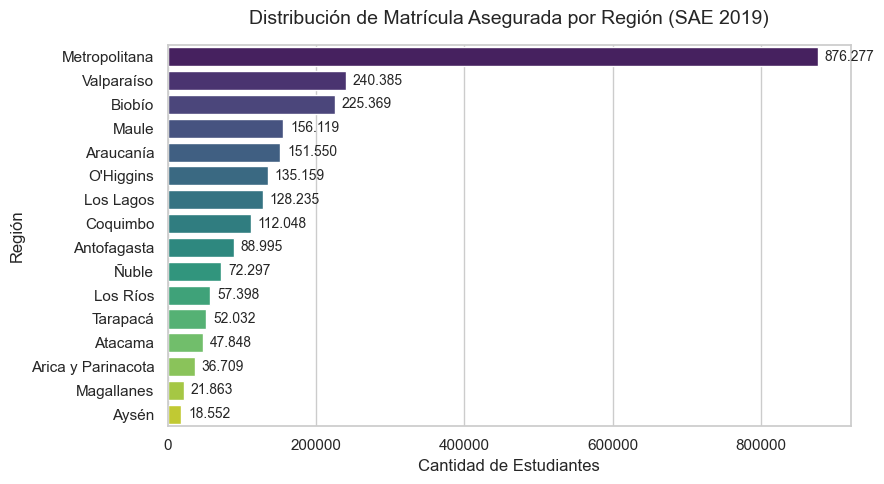

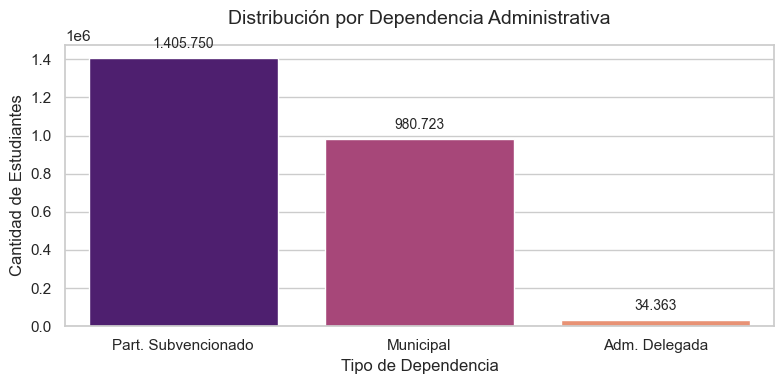

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Diccionario de traducción de códigos a nombres legibles para rápida comprensión visual.
mapa_regiones = {
    1: "Tarapacá", 2: "Antofagasta", 3: "Atacama", 4: "Coquimbo", 5: "Valparaíso",
    6: "O'Higgins", 7: "Maule", 8: "Biobío", 9: "Araucanía", 10: "Los Lagos",
    11: "Aysén", 12: "Magallanes", 13: "Metropolitana", 14: "Los Ríos", 15: "Arica y Parinacota", 16: "Ñuble"
}

mapa_depe = {
    1: 'Municipal', 2: 'Municipal', 3: 'Part. Subvencionado', 4: 'Part. Pagado', 5: 'Adm. Delegada', 6: 'Slep'
}

# Regiones
dist_reg = df_final['cod_region'].value_counts().reset_index()
dist_reg.columns = ['Región', 'Estudiantes']
dist_reg['Región'] = dist_reg['Región'].map(mapa_regiones)

print("\nConcentración de Matrícula Asegurada por Región (Top 5):")
print(dist_reg.head().to_string(index=False))

# Dependencias
dist_depe = df_final['tipo_dependencia'].map(mapa_depe).value_counts().reset_index()
dist_depe.columns = ['Dependencia', 'Total']

print("\nDistribución por Dependencia Administrativa:")
print(dist_depe.to_string(index=False))

sns.set_theme(style="whitegrid")

# Gráfico Regional
plt.figure(figsize=(9, 5))
dist_reg_sorted = dist_reg.sort_values('Estudiantes', ascending=False)

ax1 = sns.barplot(x='Estudiantes', y='Región', data=dist_reg_sorted, palette='viridis', hue='Región', legend=False)
plt.title('Distribución de Matrícula Asegurada por Región (SAE 2019)', fontsize=14, pad=15)
plt.xlabel('Cantidad de Estudiantes', fontsize=12)
plt.ylabel('Región', fontsize=12)

# Etiquetas numéricas
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_width()):,}".replace(',', '.'), 
            (p.get_width(), p.get_y() + p.get_height() / 2.),  ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

# Gráfico de Dependencia
plt.figure(figsize=(8, 4))

ax2 = sns.barplot(x='Dependencia', y='Total', data=dist_depe, palette='magma', hue='Dependencia', legend=False)
plt.title('Distribución por Dependencia Administrativa', fontsize=14, pad=15)
plt.xlabel('Tipo de Dependencia', fontsize=12)
plt.ylabel('Cantidad de Estudiantes', fontsize=12)

# Etiquetas numéricas
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height()):,}".replace(',', '.'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

---

## 6. Conclusión Ejecutiva

El procesamiento de los datos del Sistema de Admisión Escolar (SAE) 2019 revela el impacto territorial y estructural de la política de continuidad de matrícula.

* **Eficiencia del Filtro:** De un universo inicial de más de 3.5 millones de registros históricos, el algoritmo asegura la continuidad exacta y determinista de **2.525.539 estudiantes**, validando el cumplimiento estricto de las reglas de negocio (modalidad regular, alumnos activos, cálculo de edad normativa resistente a años bisiestos y cruce estructural con la oferta validada en vitrina).
* **Concentración Territorial:** La **Región Metropolitana** concentra la mayor parte de la matrícula asegurada, seguida por Valparaíso y Biobío, lo cual es coherente con la distribución demográfica nacional.
* **Estructura del Sistema Educativo:** El cruce con los datos de dependencia administrativa confirma que la oferta de continuidad se sostiene mayoritariamente sobre el sector **Particular Subvencionado** y el sector **Municipal**. Como es correcto dentro del marco regulatorio del SAE, el sector Particular Pagado no registra continuidad en este proceso.

El notebook desarrollado demuestra técnica de grado industrial en el manejo de memoria (ingesta optimizada), resolución de colisiones y validaciones de cardinalidad de datos (`many_to_one`), entregando archivos de salida listos para la integración. El flujo fue refactorizado y empaquetado en el script de producción automatizado y auditable `"pipeline_sae.py"`, contenido en la raíz de la entrega.